# Loading images to a pandas dataframe tumor or not tumor

In [13]:
import os
import io
import numpy as np
import skimage as ski
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_healthy = "./dataset/healthy"
dataset_tumor = "./dataset/tumor"
healthy_list = os.listdir(dataset_healthy)
tumor_list = os.listdir(dataset_tumor)

categories = [
    "healthy",
    "glioma",
    "meningioma",
    "pituitary",
    "tumor",
]

healthy_images = []
tumor_images = []


def categorize_img(name):
    for category in categories:
        if category in name:
            return category
    return "Unknown"


df = pd.DataFrame([], columns=["Img", "Tumor"])

# Collect original sizes
original_sizes = []

for img in healthy_list:
    read_img = ski.io.imread(dataset_healthy + "/" + img)
    original_sizes.append(read_img.shape[:2])  # height, width

for img in tumor_list:
    read_img = ski.io.imread(dataset_tumor + "/" + img)
    original_sizes.append(read_img.shape[:2])

# Normalize

Images can have different sizes or color space differences so we need to convert them to use the same color space and size, we will use size: 256x256 and Grayscale color space

In [14]:
from skimage.feature import corner_harris, corner_subpix, corner_peaks

def normalize_color_space_img(img):
    if img.ndim == 2:
        return img
    elif img.ndim == 3:
        if img.shape[2] == 4:
            return ski.color.rgb2gray(ski.color.rgba2rgb(img))
        else:
            return ski.color.rgb2gray(img)
    else:
        print(f"Unexpected image shape: {img.shape}")
        return img

def normalize_size(img):
    return ski.transform.resize(img, (256, 256), anti_aliasing=True)

for img in healthy_list:
    read_img = ski.io.imread(dataset_healthy + "/" + img)
    df.loc[len(df)] = [normalize_size(normalize_color_space_img(read_img)), 0]

for img in tumor_list:
    read_img = ski.io.imread(dataset_tumor + "/" + img)
    df.loc[len(df)] = [normalize_size(normalize_color_space_img(read_img)), 1]

# Collect sizes after resizing
resized_sizes = []

for img_data in df["Img"]:
    resized_sizes.append(img_data.shape[:2])  # height, width

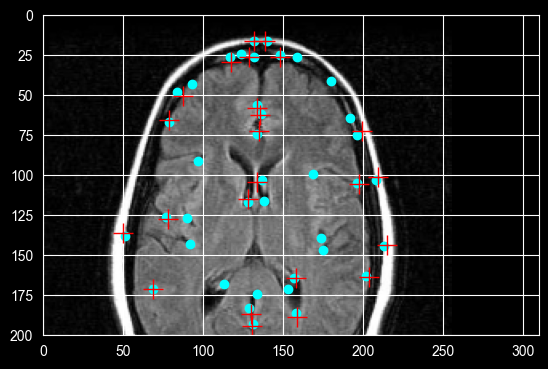

In [15]:
coords = corner_peaks(corner_harris(df["Img"][0]), min_distance=5, threshold_rel=0.02)
coords_subpix = corner_subpix(df["Img"][0], coords, window_size=13)

fig, ax = plt.subplots()
ax.imshow(df["Img"][0], cmap=plt.cm.gray)
ax.plot(
    coords[:, 1], coords[:, 0], color='cyan', marker='o', linestyle='None', markersize=6
)
ax.plot(coords_subpix[:, 1], coords_subpix[:, 0], '+r', markersize=15)
ax.axis((0, 310, 200, 0))
plt.show()